<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Data Science and Business Analytics</center></font></h1>
<h1><center>Supervised Learning - Foundations Project: ReCell </center></h1>

<center><img src="C:/Users/josep/Pictures/Recell_image.png" width="720"></center>

<center><font size=6> By Joseph Anyanwu </font></center>

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [7]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the dataset

In [8]:
# defining the location where the data is stored
file_path = 'C:/Users/josep/Downloads/used_device_data.csv'
data = pd.read_csv(file_path)

## Data Overview

In [10]:
#Viewing the first five rows of the dataset
data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [14]:
#Viewing the last five rows of the dataset
data.tail()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994


In [16]:
# to get the number of rows and columns respectively in a tuple
print(f"The data has {data.shape[0]} rows and {data.shape[1]} columns.")

The data has 3454 rows and 15 columns.


In [18]:
# check for datatypes of columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [20]:
# Getting the statistical summary for the variables
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


* We can see that the normalized price of used phones varies between 1.53 and 6.61 while the normalized price of new phones vary between 2.90 and 7.85.
* The general price of used phones is 4.36
* *Android* is the most occurring type of OS.
* The number of days the phones were used varies from 91 to 1094 days.
* The released year of the phones in the data varies from 2013 to 2020.

### Checking for duplicates and missing values

In [22]:
data.duplicated().sum()

0

There are no duplicate values in the data

In [24]:
data.isnull().sum()

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

There are no duplicate values in the data but there are missing values in many columns.

In [26]:
# creating a copy of the data so that original data remains unchanged
recell = data.copy()

## Exploratory Data Analysis (EDA)

In [28]:
def histogram_boxplot(data, feature, figsize=(10, 5), kde=True, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

* Question 1: What does the distribution of normalized used device prices look like?

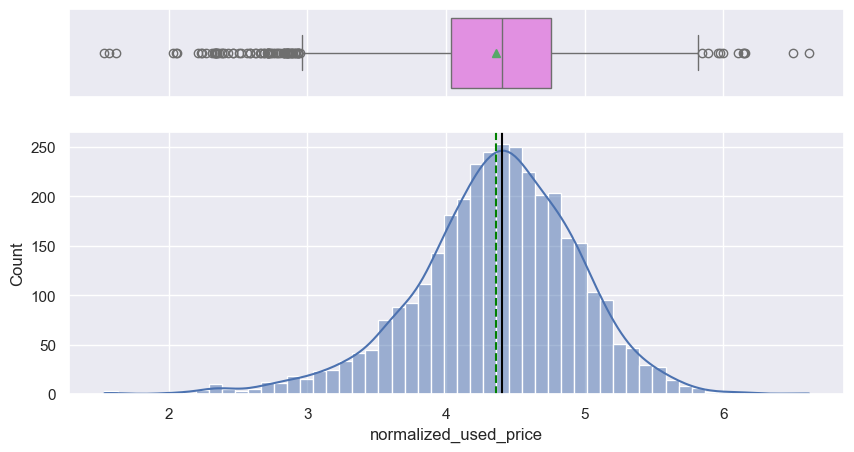

In [30]:
histogram_boxplot(recell, "normalized_used_price")

***Observation***
*  *The distribution of normalized used device prices follows a normal distribution*
*   *50% of the normalized used device prices lies between 4 and 4.5.*
*   *The normalized used device prices have some outliers showing some folks spent more than the average price.*
*   *The average normalized used device prices is around 4.36*

In [34]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None, title=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
      if p.get_height() > 0:  # Exclude zero-height bars
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="bottom",  # Ensures label is placed above the bar
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )
    if title:  # Add title if provided
        plt.title(title, fontsize=14)

    plt.show()  # show the plot

* Question 2: What percentage of the used device market is dominated by Android devices?

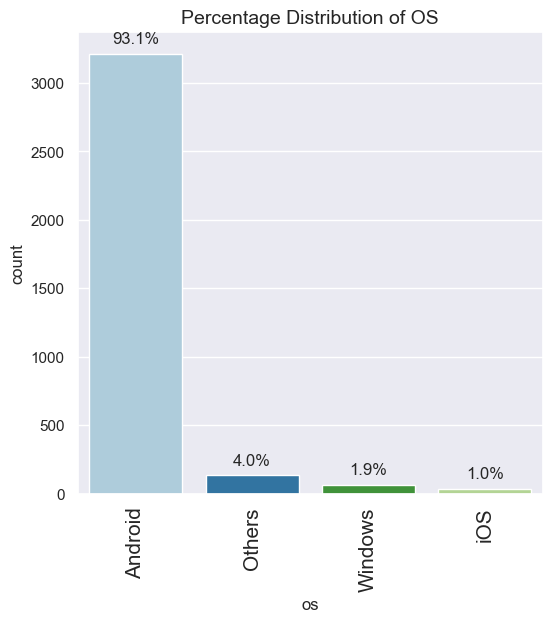

In [36]:
labeled_barplot(recell, "os", perc=True, title = 'Percentage Distribution of OS')

In [38]:
# What percentage of the used device market is dominated by Android devices?
print(recell["os"].value_counts(normalize=True) * 100) # calculate the percentage of each operating system (OS) present in the recell DataFrame
print('--'*50)
print(f"{round(recell['os'].value_counts(normalize=True)['Android'] * 100, 2)}% of the used device market is dominated by Android devices.")
#round(recell["os"].value_counts(normalize=True).iloc[0] * 100, 2) # selects the first element of the result from value_counts().

os
Android    93.051534
Others      3.966416
Windows     1.939780
iOS         1.042270
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
93.05% of the used device market is dominated by Android devices.


***Observation***

*93.05% of the used device market is dominated by Android devices.*

* Question 3:  How does the amount of RAM vary with the brand?

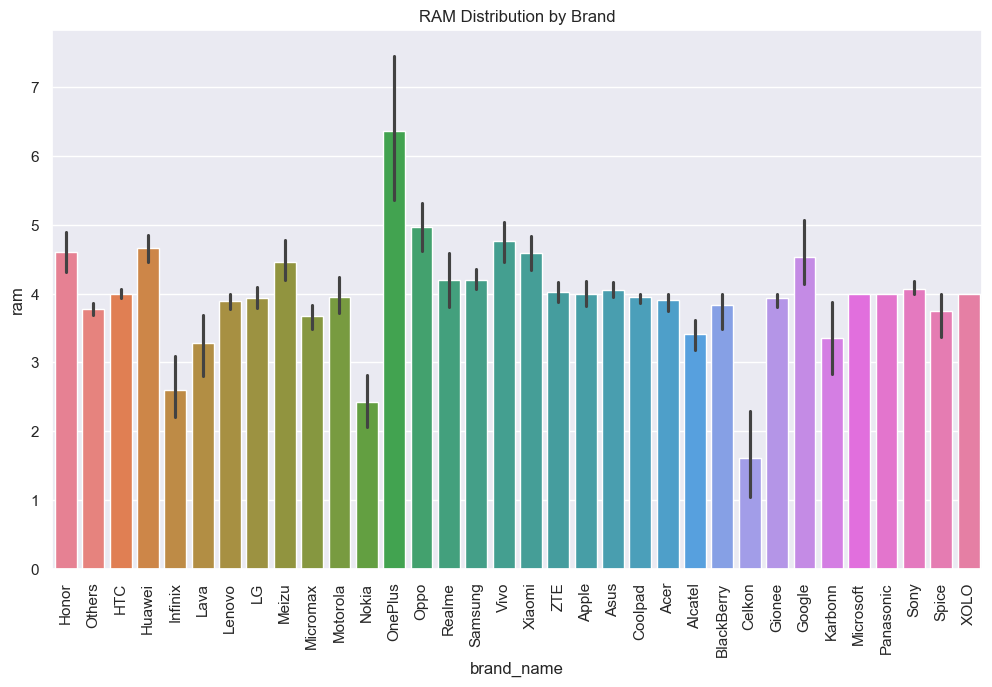

In [40]:
# How does the amount of RAM vary with the brand?

plt.figure(figsize=(12, 7))
sns.barplot(x="brand_name", y="ram", data=recell, hue = 'brand_name')
plt.title("RAM Distribution by Brand")
plt.xticks(rotation=90)
plt.show()

In [42]:
# How does the amount of RAM vary with the brand?
large_ram_percent = round(recell[ (recell['ram'] > 4)].shape[0] / recell.shape[0] *100,2) # recell.shape[0] used to get total rows
small_ram_percent = round(recell[ (recell['ram'] <= 4)].shape[0] / recell.shape[0] *100,2)


print(f"{small_ram_percent}% of the phones have less than or equal to 4 GB")
print(f"{large_ram_percent}% of the phones have more than 4 GB")

91.14% of the phones have less than or equal to 4 GB
8.74% of the phones have more than 4 GB


***Observation***

* *The plot shows that while most brands maintain RAM within a specific range (3 - 5), some outliers like OnePlus and Realme push towards higher memory capacities.*
* *Brands like Apple, Google, and Asus offer a balance between RAM and other phone features, aiming for a wider user base.*
* *91.14% of the phones have less than 4 GB while 8.74% of the phones have more than 4 GB. The remaining 0.12 is due to the missing data *

* **Question 4**: A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?

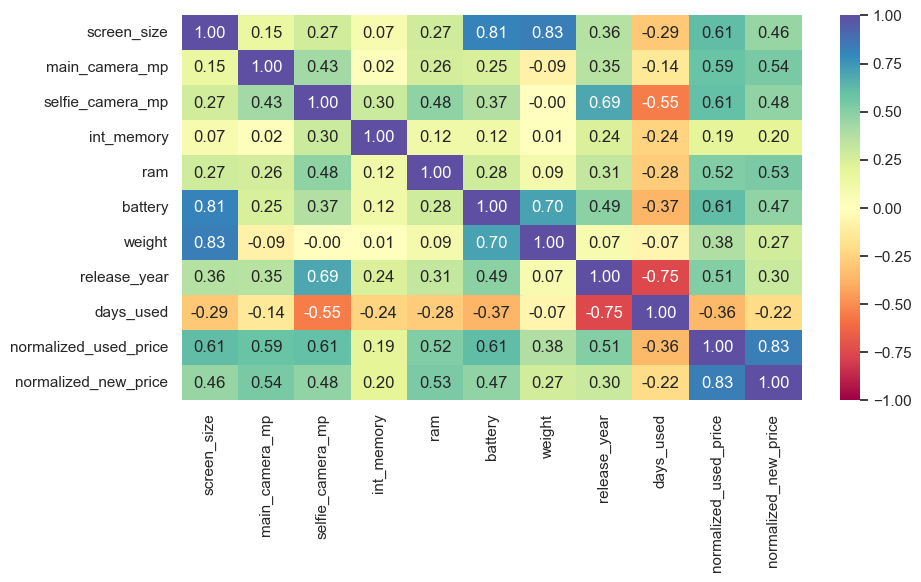

In [44]:
# show correlation of columns
# creating a list of numerical columns
num_cols = recell.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    recell[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show();

*From the given data, we observed that the battery and weight have a very high positive correlation.*

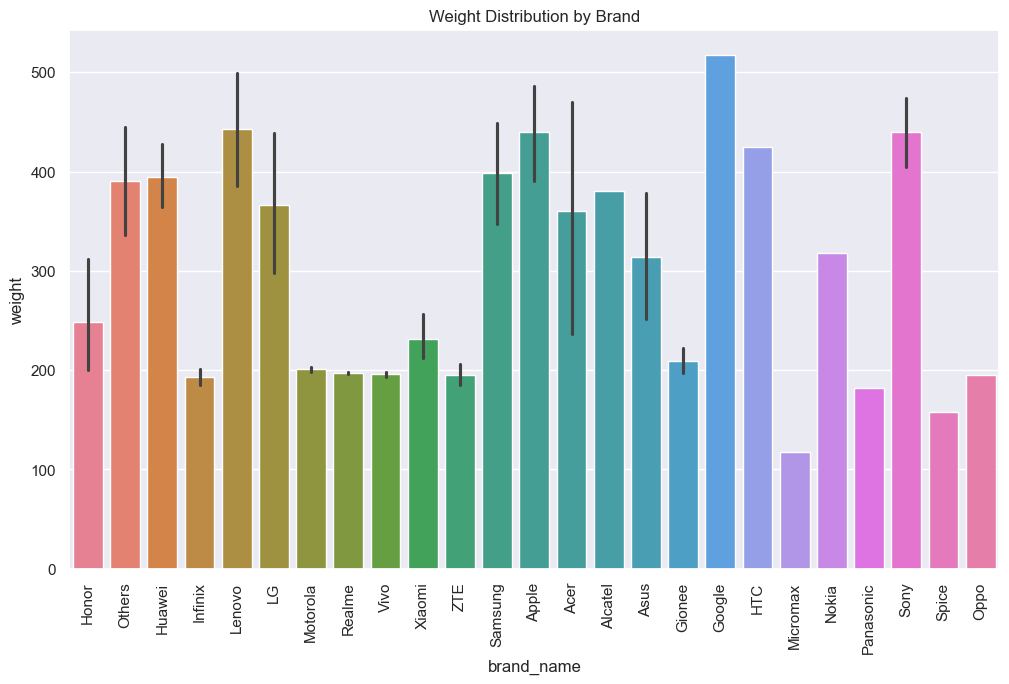

In [46]:
# How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
plt.figure(figsize=(12, 7))
sns.barplot(x="brand_name", y="weight", data=recell[recell["battery"] > 4500], hue = 'brand_name')
plt.title("Weight Distribution by Brand")
plt.xticks(rotation=90)
plt.show()

In [48]:
# how many percent of the phones offering large batteries (more than 4500 mAh) have weight over 300?
large_battery_percent = round(recell[(recell['battery'] > 4500) & (recell['weight'] > 300)].shape[0] / recell[recell['battery'] > 4500].shape[0] *100,2)
small_battery_percent = round(recell[(recell['battery'] > 4500) & (recell['weight'] <= 300)].shape[0] / recell[recell['battery'] > 4500].shape[0] *100,2)


print(f"{small_battery_percent}% of the phones offering large batteries (more than 4500 mAh) have weight less or equal to 300.")
print(f"{large_battery_percent}% of the phones offering large batteries (more than 4500 mAh) have weight over 300.")

50.15% of the phones offering large batteries (more than 4500 mAh) have weight less or equal to 300.
49.85% of the phones offering large batteries (more than 4500 mAh) have weight over 300.


***Observation***

* *The battery and weight have a very high positive correlation.*
* *50.15% of the phones offering large batteries (more than 4500 mAh) have weight less or equal to 300.*
* *49.85% of the phones offering large batteries (more than 4500 mAh) have weight over 300.*

* **Question 5**: Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?

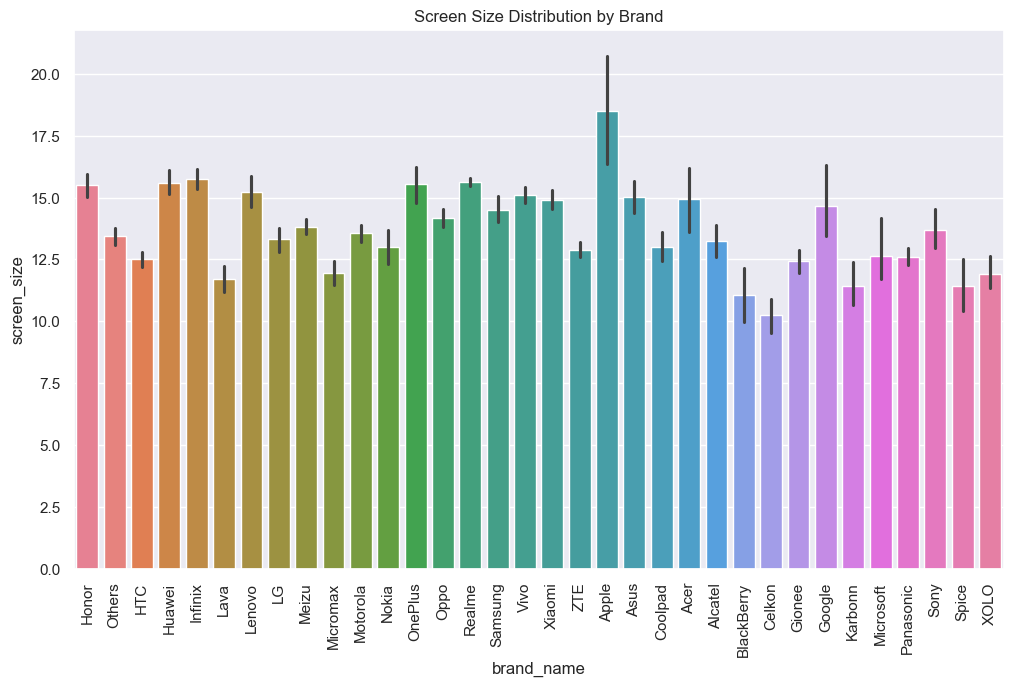

----------------------------------------------------------------------------------------------------
3362 phones and tablets are available across different brands with a screen size larger than 6 inches.
3362 phones and tablets are available across different brands with a screen size larger than 6 inches.


In [50]:
# How many phones and tablets are available across different brands with a screen size larger than 6 inches?
plt.figure(figsize=(12, 7))
sns.barplot(x="brand_name", y="screen_size", data=recell[recell["screen_size"] > 6], hue = 'brand_name')
plt.title("Screen Size Distribution by Brand")
plt.xticks(rotation=90)
plt.show();

print('--'*50)

# no of phones and tablets are available across different brands with a screen size larger than 6 inches.
print(f"{recell[recell['screen_size'] > 6].shape[0]} phones and tablets are available across different brands with a screen size larger than 6 inches.")

# OR

bb = recell[recell['screen_size'] > 6].groupby('brand_name')['screen_size'].count().sum()
print(bb,"phones and tablets are available across different brands with a screen size larger than 6 inches.")

***Observation***

*3,362 phones and tablets are available across different brands with a screen size larger than 6 inches.*

**Question 6:** A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?

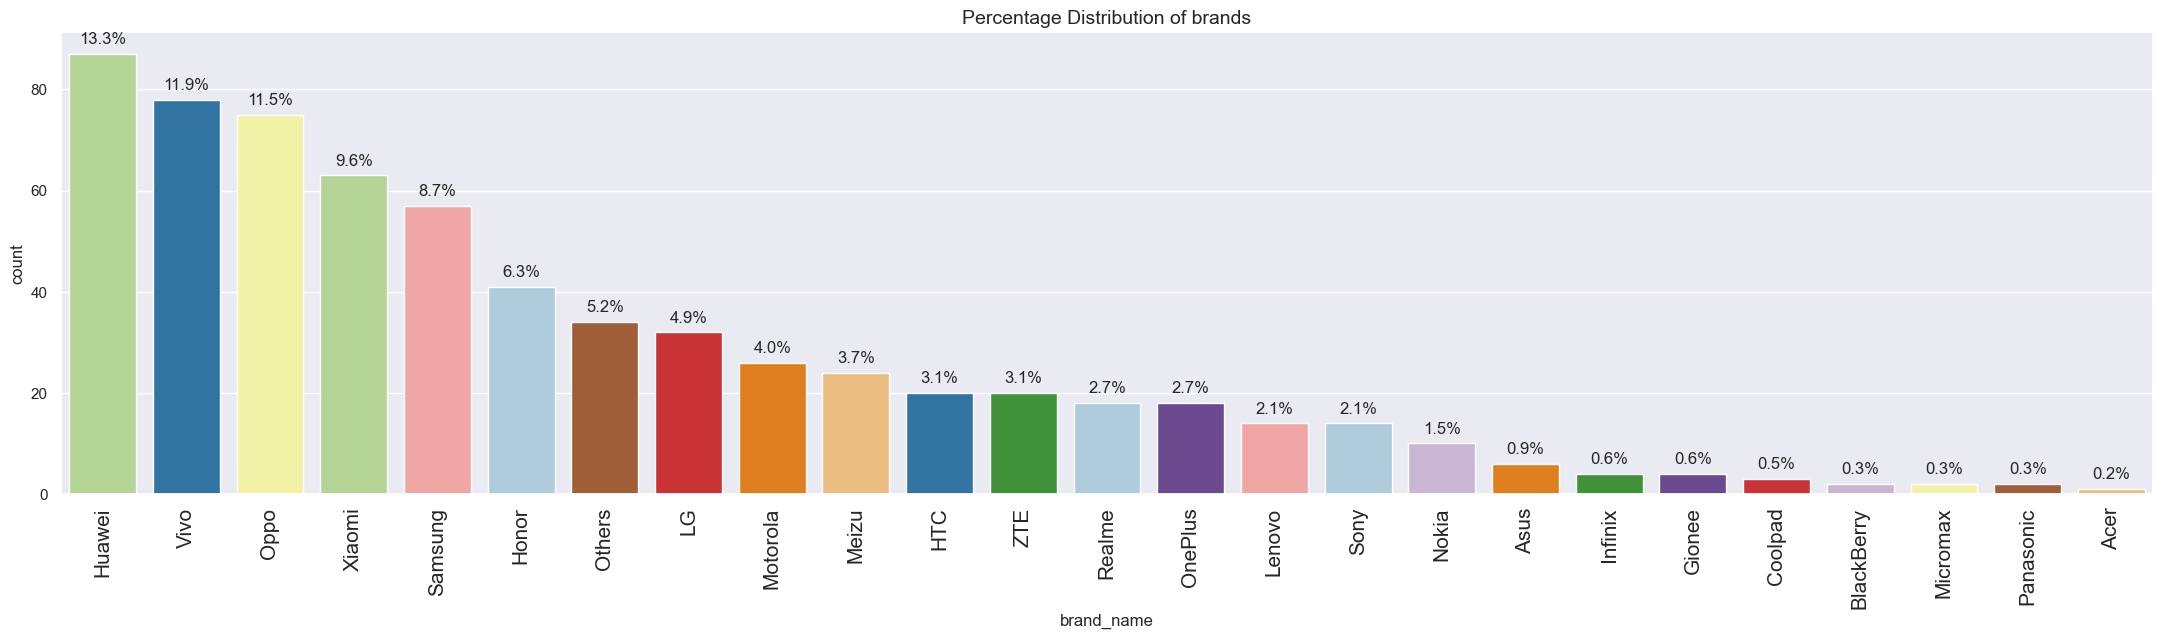

In [52]:
# Filter devices with selfie cameras greater than 8MP
selfie = recell[recell['selfie_camera_mp'] > 8]
#device_count = recell.loc[recell['selfie_camera_mp'] > 8]

'''
# Group by brand and count the number of devices per brand
brand_dist = selfie['brand_name'].value_counts()


# Plot the distribution
plt.figure(figsize=(12,6))
sns.barplot(x=brand_dist.index, y=brand_dist.values, hue = brand_dist.index, legend = False)
plt.xlabel('Brand')
plt.ylabel('Number of Devices')
plt.title('Distribution of Devices with >8MP Selfie Cameras Across Brands')
plt.xticks(rotation=90)  # Rotate brand names for readability
plt.show();
'''

labeled_barplot(selfie, 'brand_name', perc=True, title = 'Percentage Distribution of brands')

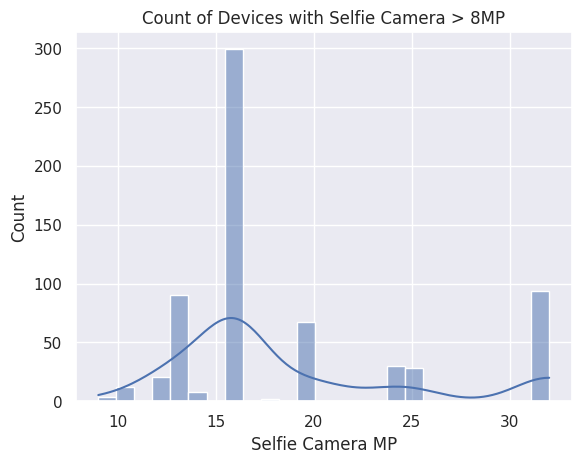

In [23]:
device_count = recell.loc[recell['selfie_camera_mp'] > 8]
sns.histplot(data=device_count, x="selfie_camera_mp", kde=True)
plt.xlabel('Selfie Camera MP')
plt.ylabel('Count')
plt.title('Count of Devices with Selfie Camera > 8MP')


plt.show();

#sns.barplot(data=device_count, x='brand_name', y='selfie_camera_mp', hue = 'brand_name', legend = False)


***Observation***

* *The KDE (Kernel Density Estimation) line suggests a multimodal distribution, meaning there are multiple common selfie camera resolutions rather than a normal distribution.*
* *The significant spikes at around 16 MP, 13 MP, 20 MP, and 32 MP suggest that most selfie cameras in the dataset have this resolution.*
* *Among devices with selfie cameras greater than 8MP, Huawei has the highest count, accounting for more than 13% of such devices followed by Vivo and Oppo brands with ~12% respectively.*

**Question 7**: Which attributes are highly correlated with the normalized price of a used device?

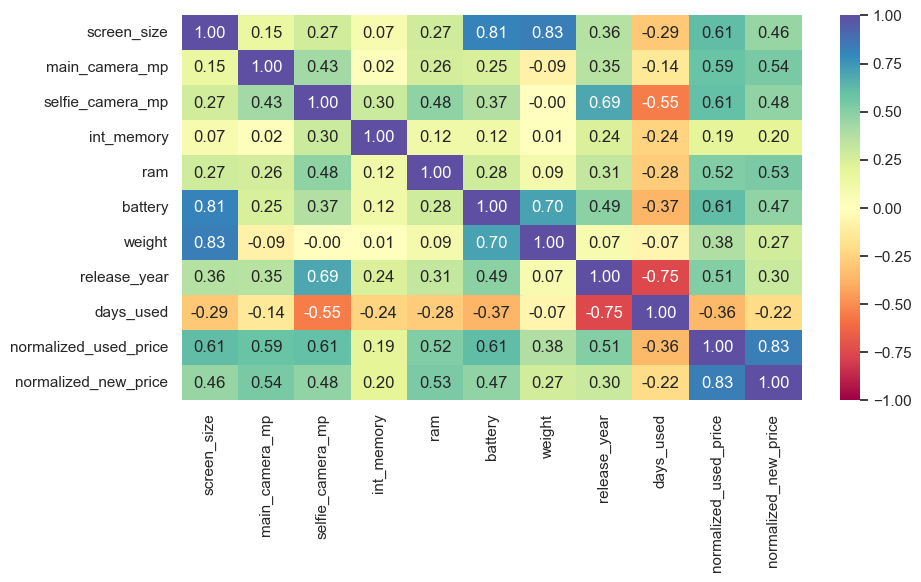

------------------------------------------------------------------------------------------------------------------------------------------------------
the attributes that are highly correlated with the normalized price of a used device are:
['normalized_new_price', 'screen_size', 'battery', 'selfie_camera_mp', 'main_camera_mp', 'ram', 'release_year']


In [54]:
# Which attributes are highly correlated with the normalized price of a used device?

#num_cols = recell.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = recell[num_cols].corr()

# Visualize correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    recell[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show();

# Get correlations with normalized price and sort ascending
price_correlation = correlation_matrix['normalized_used_price'].sort_values(ascending=False)

# Define high correlation threshold as correlation value >= 0.5
high_correlation_threshold = 0.5

# Filter attributes with high correlation (excluding 'normalized_used_price' itself)

highly_correlated_cols = price_correlation[price_correlation >=high_correlation_threshold].index.tolist()
highly_correlated_cols.remove("normalized_used_price")  # Remove target column if present

#highly_correlated_attributes = price_correlation.tail(len(price_correlation)-1)[price_correlation >= threshold].index.tolist() # Exclude target column from the list

print('---'*50)

print(f"the attributes that are highly correlated with the normalized price of a used device are:")
print(highly_correlated_cols)

#price_correlation.tail(len(price_correlation)-1).index.tolist()



**Observations**

The attributes that are highly correlated with the normalized price of a used device are: 'normalized_new_price', 'screen_size', 'battery', 'selfie_camera_mp', 'main_camera_mp', 'ram', 'release_year'

**Insights & Recommendations**
* The new price is the strongest predictor of the used price, which is expected.
* Battery life, screen size, and cameras significantly affect resale value.
RAM and device age (release year) are important considerations.
* Usage duration (days_used) negatively affects price, meaning older devices lose value over time.
* Internal memory (storage) is less impactful than expected—perhaps because cloud storage and expandable storage reduce its influence.


## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## Missing Value Treatment

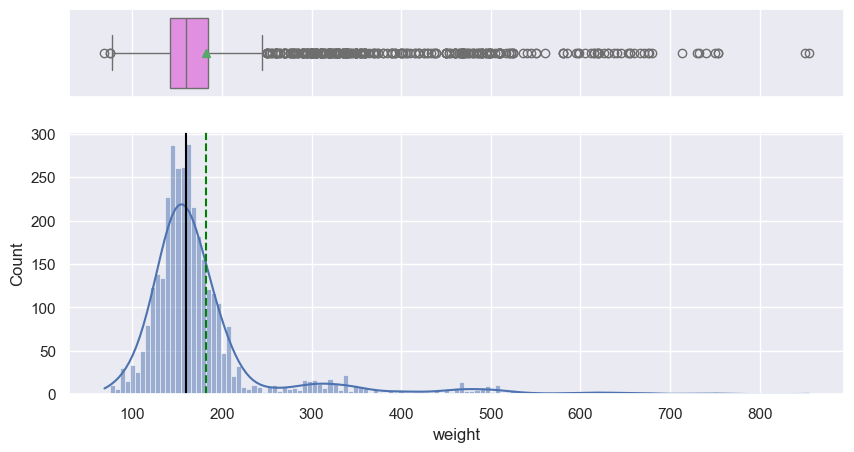

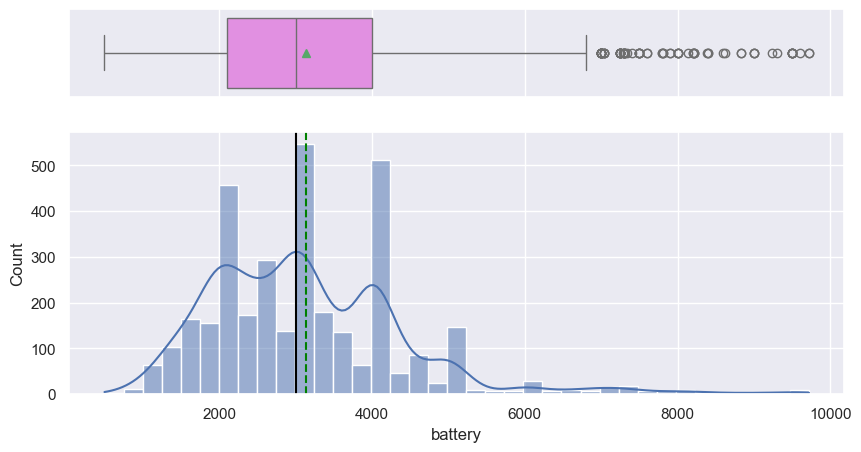

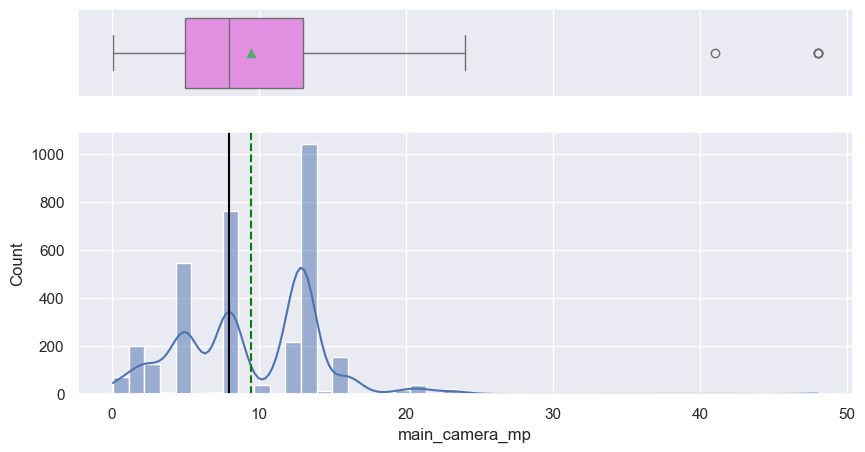

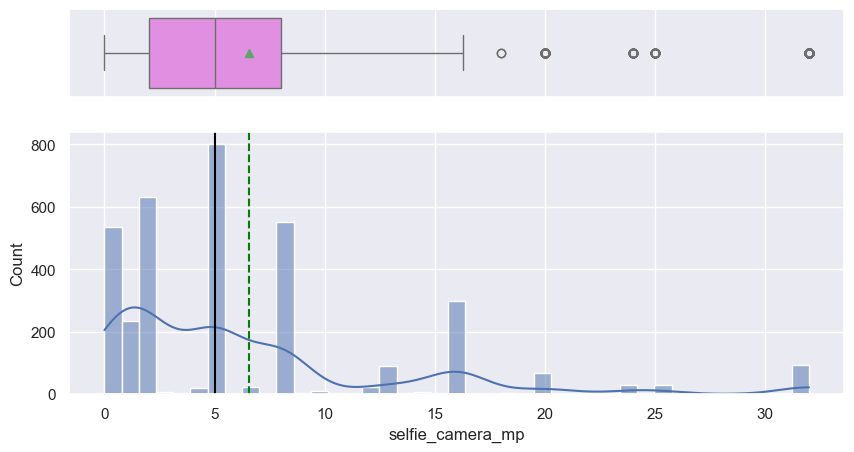

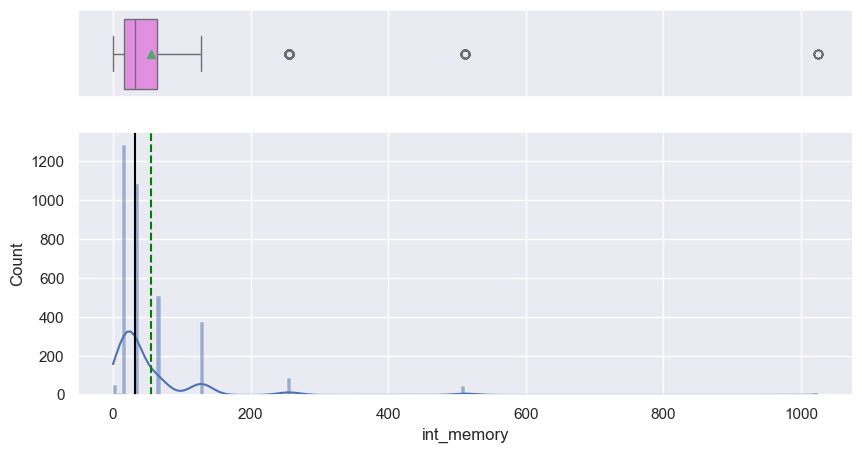

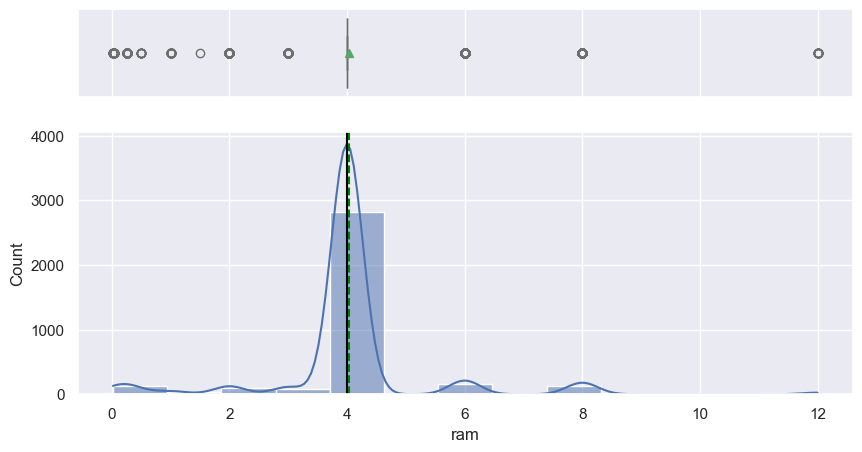

In [56]:
# Plots to check distribution of some number columns
histogram_boxplot(recell, "weight")
histogram_boxplot(recell, "battery")
histogram_boxplot(recell, "main_camera_mp")
histogram_boxplot(recell, "selfie_camera_mp")
histogram_boxplot(recell, "int_memory")
histogram_boxplot(recell, "ram")


In [58]:
# we first create a copy of the data to avoid changes to it
df = data.copy()

In [62]:
# check for empty or missing data
df.isnull().sum()

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

To fix the missing values for `main_camera_mp`, `selfie_camera_mp`, `ram`, `internal memory`, `battery`, and `weight`.

We will impute the missing values in each column with the median for numerical columns and mode for categorical-like numerical columns because they are all skewed in their distributions.

In [65]:
# Fill missing values with median for numerical columns
df["main_camera_mp"] = df["main_camera_mp"].fillna(
    value=df.groupby(["os", "brand_name"])["main_camera_mp"].transform("median")
)

df["battery"] = df["battery"].fillna(
    value=df.groupby(["os", "brand_name"])["battery"].transform("median")
)

df["weight"] = df["weight"].fillna(
    value=df.groupby(["os", "brand_name"])["weight"].transform("median")
)

# Fill missing values with mode for categorical-like numerical columns
mode_cols = ['int_memory', 'ram', 'selfie_camera_mp']
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if missing values are handled
print("Missing values after treatment:")
print(" ")
print(df.isnull().sum())

Missing values after treatment:
 
brand_name                0
os                        0
screen_size               0
4g                        0
5g                        0
main_camera_mp           10
selfie_camera_mp          0
int_memory                0
ram                       0
battery                   0
weight                    0
release_year              0
days_used                 0
normalized_used_price     0
normalized_new_price      0
dtype: int64


* Since we still have missing values in `main_camera_mp` column, We will impute the remaining missing values  with the median grouped by `os`

In [68]:
df["main_camera_mp"] = df["main_camera_mp"].fillna(
    value=df.groupby(["os"])["main_camera_mp"].transform("median")
)

df.isnull().sum()

brand_name               0
os                       0
screen_size              0
4g                       0
5g                       0
main_camera_mp           0
selfie_camera_mp         0
int_memory               0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64

* All the missing values have been treated.

## Outlier Detection

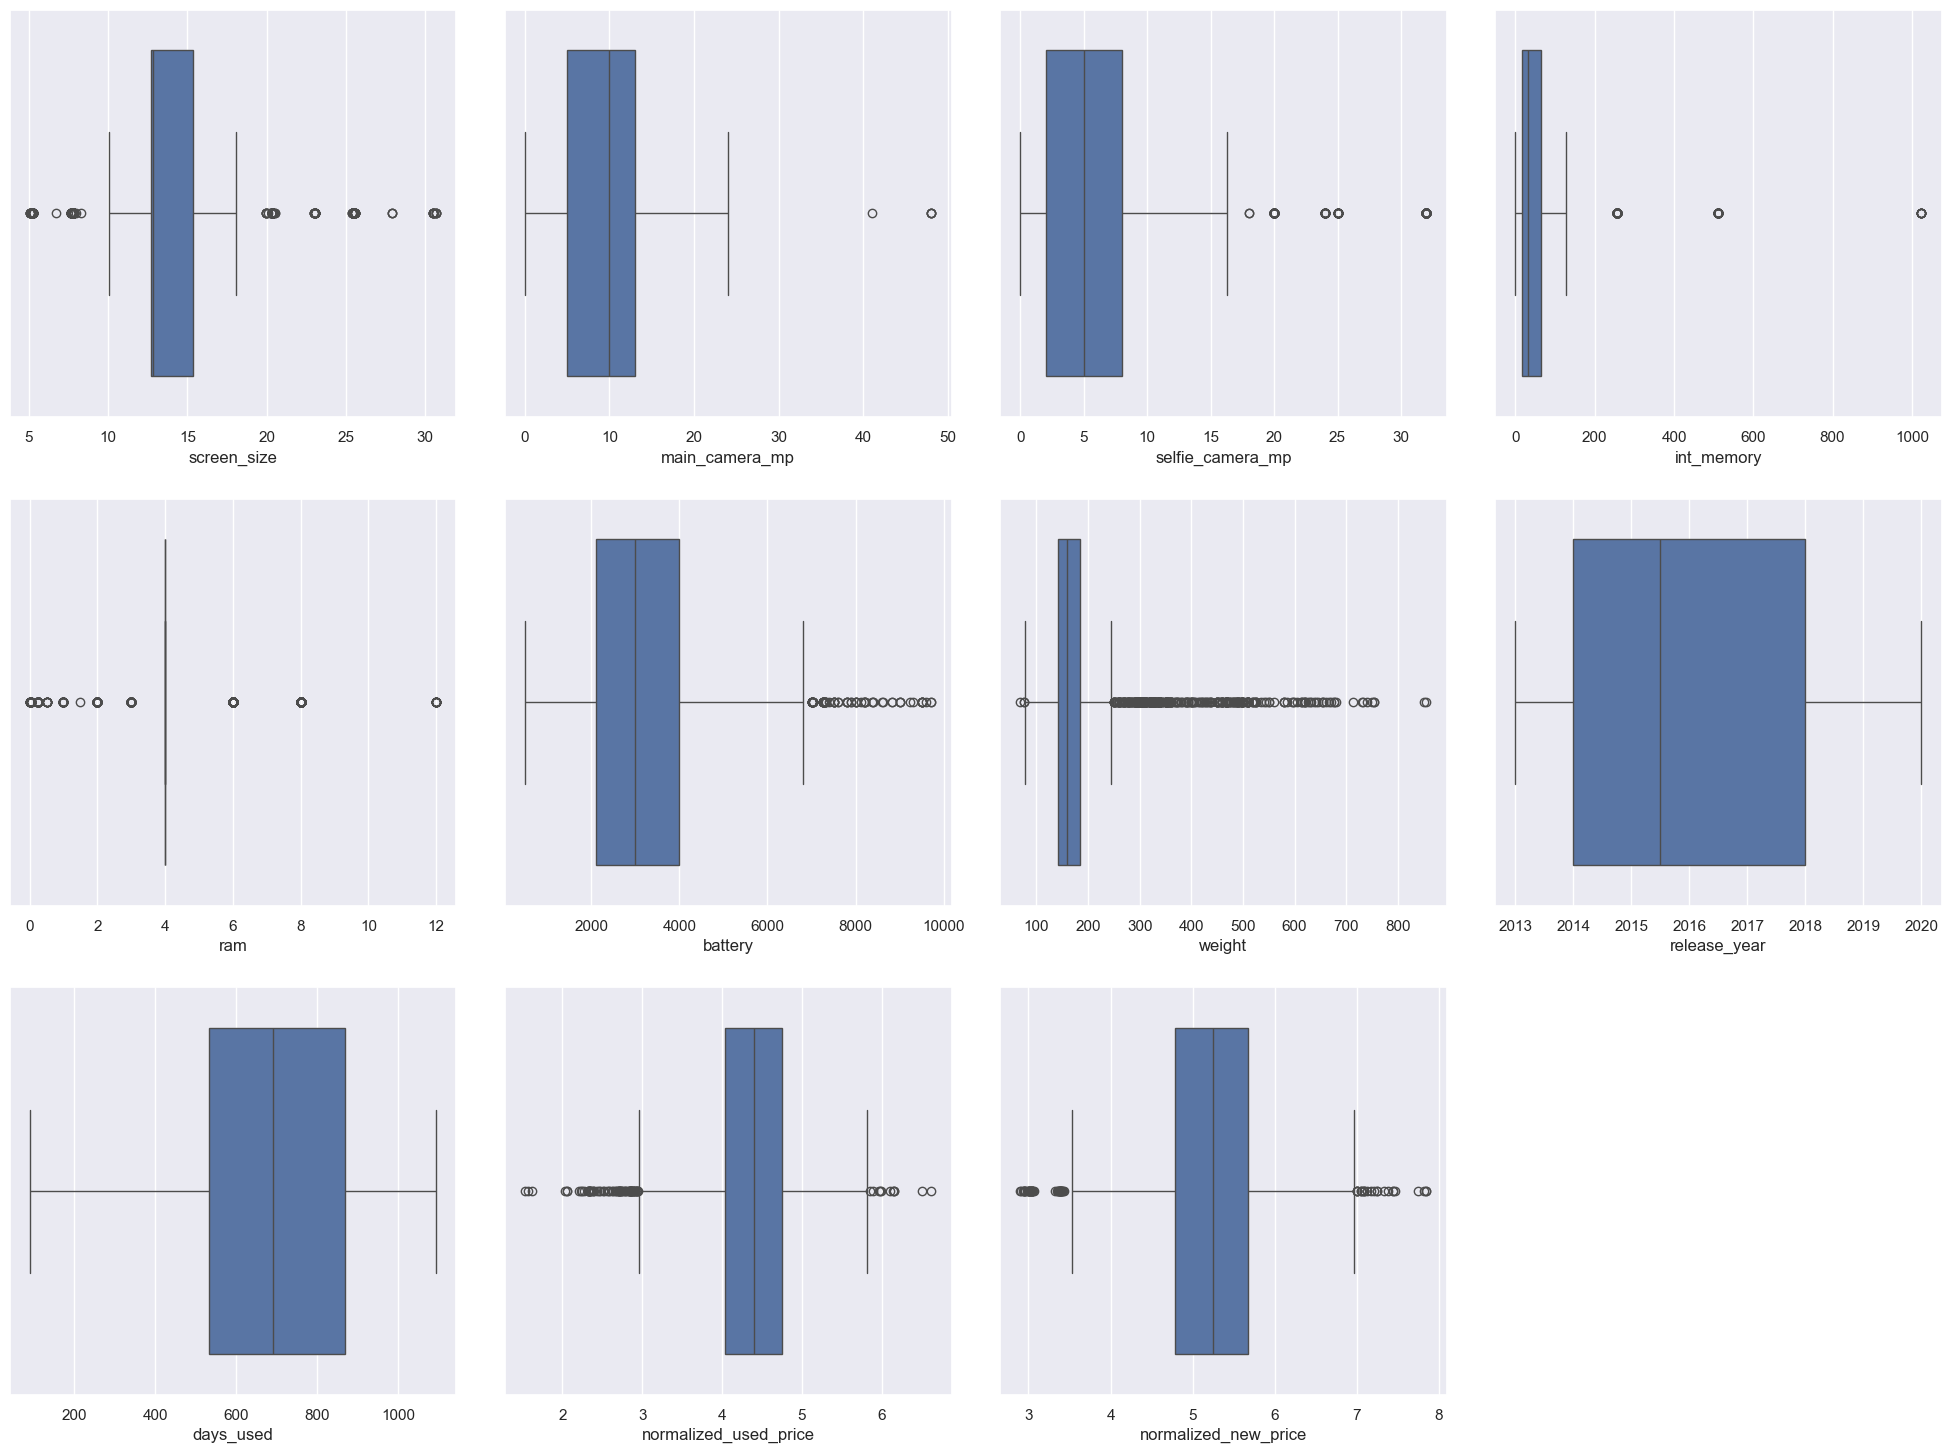

In [70]:
# outlier detection using boxplot
numb_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculate the number of rows and columns for subplots
num_rows = int(np.ceil(len(numb_cols) / 4))  # Calculate rows needed

plt.figure(figsize=(20, 5 * num_rows))  # Adjust figure size for more subplots

for i, variable in enumerate(numb_cols):
    plt.subplot(num_rows,4, i + 1)  # Use calculated rows, 3 columns
    sns.boxplot(data=df, x=variable)

plt.tight_layout(pad=2)
plt.show();


After treating the missing values, we still observe outliers in the data, but since they are coming from correct data, we will let them be.

## Model Building - Linear Regression

**Steps of Data Preparation for Modeling**

* The goal is to predict the normalized used price of phones.
* Before we proceed to build a model, we'll have to encode categorical features
* Split the data into train and test to be able to evaluate the model that we build on the train data
* Build a Linear Regression model using the train data and then check it's performance

In [72]:
# creating dummy variables for the categorical columns
df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
df.head(10)

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,...,False,False,False,False,False,False,False,False,True,False
1,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,...,False,False,False,False,False,False,False,False,True,True
2,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,...,False,False,False,False,False,False,False,False,True,True
3,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,...,False,False,False,False,False,False,False,False,True,True
4,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,...,False,False,False,False,False,False,False,False,True,False
5,16.23,13.0,8.0,64.0,4.0,4000.0,176.0,2020,223,4.413889,...,False,False,False,False,False,False,False,False,True,False
6,13.84,8.0,5.0,32.0,2.0,3020.0,144.0,2020,234,3.878259,...,False,False,False,False,False,False,False,False,True,False
7,15.77,13.0,8.0,64.0,4.0,3400.0,164.0,2020,219,4.729421,...,False,False,False,False,False,False,False,False,True,False
8,15.32,13.0,16.0,128.0,6.0,4000.0,165.0,2020,161,4.886054,...,False,False,False,False,False,False,False,False,True,False
9,16.23,13.0,8.0,128.0,6.0,4000.0,176.0,2020,327,4.773224,...,False,False,False,False,False,False,False,False,True,False


In [74]:
# converting the input attributes into float type for modeling
df = df.astype(float)
df.head()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,2020.0,127.0,4.307572,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,2020.0,325.0,5.162097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,2020.0,162.0,5.111084,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,2020.0,345.0,5.135387,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,2020.0,293.0,4.389995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [267]:
# Check data types
print(df.dtypes)  # Ensure all columns are numeric

screen_size              float64
main_camera_mp           float64
selfie_camera_mp         float64
int_memory               float64
ram                      float64
battery                  float64
weight                   float64
release_year             float64
days_used                float64
normalized_used_price    float64
normalized_new_price     float64
brand_name_Alcatel       float64
brand_name_Apple         float64
brand_name_Asus          float64
brand_name_BlackBerry    float64
brand_name_Celkon        float64
brand_name_Coolpad       float64
brand_name_Gionee        float64
brand_name_Google        float64
brand_name_HTC           float64
brand_name_Honor         float64
brand_name_Huawei        float64
brand_name_Infinix       float64
brand_name_Karbonn       float64
brand_name_LG            float64
brand_name_Lava          float64
brand_name_Lenovo        float64
brand_name_Meizu         float64
brand_name_Micromax      float64
brand_name_Microsoft     float64
brand_name

All the variables are now in float data type with no missing values

Split Data

In [76]:
# defining X and y variables
X = df.drop(["normalized_used_price"], axis=1)   #excluding the normalized_used_price as the target
y = df["normalized_used_price"]  # target



In [78]:
# let's add the intercept to data
X = sm.add_constant(X)

In [80]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [271]:
print(x_train.head())
print(x_test.head())

      const  screen_size  main_camera_mp  selfie_camera_mp  int_memory  ram  \
3026    1.0        10.29             8.0               0.3        16.0  4.0   
1525    1.0        15.34            13.0               5.0        32.0  4.0   
1128    1.0        12.70            13.0               5.0        32.0  4.0   
3003    1.0        12.83             8.0               5.0        16.0  4.0   
2907    1.0        12.88            13.0              16.0        16.0  4.0   

      battery  weight  release_year  days_used  ...  brand_name_Spice  \
3026   1800.0   120.0        2014.0      819.0  ...               0.0   
1525   4050.0   225.0        2016.0      585.0  ...               0.0   
1128   2550.0   162.0        2015.0      727.0  ...               0.0   
3003   3200.0   132.0        2015.0      800.0  ...               0.0   
2907   2900.0   160.0        2017.0      560.0  ...               0.0   

      brand_name_Vivo  brand_name_XOLO  brand_name_Xiaomi  brand_name_ZTE  \
3026     

In [82]:
# get the number of rows in train and test data

print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])
#print(data.shape)

Number of rows in train data = 2417
Number of rows in test data = 1037


Model Building - Linear Regression

In [84]:
olsmodel = sm.OLS(y_train, x_train)
results = olsmodel.fit()
print(results.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.4
Date:                   Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                           22:52:04   Log-Likelihood:                 122.70
No. Observations:                   2417   AIC:                            -147.4
Df Residuals:                       2368   BIC:                             136.3
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


**Interpreting the Regression Results:**

1. **R-squared**:  tells me what percentage of the variance in the data the model can explain.
    - In this case, the value for R-squared is **0.845**, meaning that the model can explain 84.5% of the variance in the training set, which is good.

2. **Adjusted. R-squared**: It reflects the fit of the model, where the closer the value is to 1.0, the better, assuming certain conditions are met.
    - In this case, the value for adj. R-squared is **0.842**, which is good.

3. ***const* coefficient**: It is the Y-intercept.
    - It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the *const* coefficient.
    - In this case, the value for `const` coefficient is **-46.2732**


4. **Coefficient of a predictor variable**: It represents the change in the output Y due to a change in the predictor variable (everything else held constant).
    - In our case, the coefficient of `main camera mp` is **0.0207** while that of `ram` is **0.0232**.

## Model Performance Check

check the performance of the model using the metrics below.
* Root Mean Square (RMSE)
* Mean Absolute Error (MAE)
* Mean Absolute Percentage Error (MAPE)
* Adj. $R^2$ and $R^2$

We will create a function which will print out all the above metrics in one go.

In [86]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    """
    Function to compute adjusted R-squared

    predictors: independent variables
    targets: dependent variables
    predictions: predicted values
    """

    r2 = r2_score(targets, predictions) # calculating the regular R-squared value using the r2_score function
    n = predictors.shape[0] #  number of observations (data points) = number of rows in the predictors dataframe
    k = predictors.shape[1] #  number of predictors (independent variables) in the model = number of columns in the predictors
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1)) # returns the calculated Adjusted R-squared value.


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [88]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(results, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.229994,0.180383,0.844737,0.841523,4.328681


In [90]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(results, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238766,0.185031,0.841939,0.834092,4.50981


**Observations**

- The training $R^2$ is 0.84, so the model is not underfitting.

- The train and test RMSE and MAE are comparable, so the model is not overfitting either.

- MAE suggests that the model can predict anime ratings within a mean error of ~0.19 on the test data.

- MAPE of 4.5 on the test data means that we are able to predict within 4.5% of the normalized used price of the devices.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

**TEST FOR MULTICOLLINEARITY** using the Variance Inflation Factor (VIF).

* **Variance  Inflation Factor (VIF)**:  Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors.


* **General Rule of thumb**:
    - If VIF is between 1 and 5, then there is low multicollinearity.
    - If VIF is between 5 and 10, we say there is moderate multicollinearity.
    - If VIF is exceeding 10, it shows signs of high multicollinearity.

*Start by defining a function to check VIF*

In [103]:
# defining a function to check VIF

# import required library
from statsmodels.stats.outliers_influence import variance_inflation_factor

def checking_vif(predictors):
    """
    Function to calculate Variance Inflation Factor (VIF) for a given dataset.

    Parameters:
    predictors (pd.DataFrame): The dataframe containing independent variables.

    Returns:
    pd.DataFrame: A dataframe showing VIF values for each feature.
    """

    vif = pd.DataFrame()  # creating dataframe for storing VIF
    vif["feature"] = predictors.columns  # storing the feature names in the dataframe

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]  # storing the VIF values in the dataframe

    # Convert large exponential values to readable format in 2 decimal places
    vif["VIF"] = vif["VIF"].apply(lambda x: round(x, 2) if x < 1e9 else np.inf)

    return vif



In [105]:
# get VIF results on the train data
vif_results = checking_vif(x_train).sort_values(by="VIF", ascending=False)
print(vif_results)

                  feature         VIF
0                   const  3792547.55
12       brand_name_Apple       13.06
46                 os_iOS       11.78
34      brand_name_Others        9.71
1             screen_size        7.67
37     brand_name_Samsung        7.54
7                  weight        6.39
21      brand_name_Huawei        5.98
8            release_year        4.90
24          brand_name_LG        4.85
26      brand_name_Lenovo        4.56
6                 battery        4.09
33        brand_name_Oppo        3.97
43         brand_name_ZTE        3.80
42      brand_name_Xiaomi        3.72
40        brand_name_Vivo        3.65
31       brand_name_Nokia        3.47
11     brand_name_Alcatel        3.41
19         brand_name_HTC        3.41
28    brand_name_Micromax        3.36
20       brand_name_Honor        3.34
13        brand_name_Asus        3.33
30    brand_name_Motorola        3.27
10   normalized_new_price        3.12
38        brand_name_Sony        2.94
3        sel

There are multiple columns with very high VIF values, indicating presence of strong multicollinearity
- We will systematically drop numerical columns with VIF > 5
- We will ignore the VIF values for dummy variables and the constant (intercept)

### Removing Multicollinearity

To remove multicollinearity

1. Drop every column one by one that has a VIF score greater than 5.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 5.

Start by defining a function that will accomplish this.

In [99]:
# define function To remove multicollinearity

def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously

    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]
        '''
        the above code selects all rows and the columns that do not start with the name of the current high-VIF column.
        This essentially creates a new DataFrame called train with the potentially problematic column removed.
        '''
        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [107]:
# Defining high VIF features based on a threshold of 5
high_vif_features = vif_results[vif_results['VIF'] > 5]['feature'].tolist() #select only rows where the VIF value is greater than 5
cols_list = high_vif_features

# calling the function and storing the result into variable called res.
res = treating_multicollinearity(x_train, y_train, cols_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,const,0.997192,0.233537
1,brand_name_Apple,0.841657,0.232312
2,brand_name_Huawei,0.841657,0.232312
3,brand_name_Others,0.841655,0.232314
4,os_iOS,0.841644,0.232322
5,brand_name_Samsung,0.841621,0.232338
6,screen_size,0.838209,0.234828
7,weight,0.837937,0.235025


Ignoring the constant and dummy variables for now, we select a features (main columns) with adj.$R^2$ closer to model's because it implies it has less effect on the model when dropped.

First, we drop `screen_size` and `weight`column because it is closest to the original $R^2$

In [109]:
col_to_drop1 = ["screen_size", "weight"]
 #["brand_name_Apple","brand_name_Others"]
# Create a boolean mask for columns to keep
# "battery", "weight", "ram", "days_used",
mask = [not any(col.startswith(prefix) for prefix in col_to_drop1) for col in x_train.columns]
# It iterates through each column (col) in the x_train2 and apply mask to column name that does not start with any of the prefixes to be dropped
x_train2 = x_train.loc[:, mask]
x_test2 = x_test.loc[:, mask]

# Check VIF now
vif_results2 = checking_vif(x_train2).sort_values(by="VIF", ascending=False)
print("VIF values after dropping ", col_to_drop1)
vif_results2

VIF values after dropping  ['screen_size', 'weight']


,feature,VIF
0,const,3643420.28
10,brand_name_Apple,12.98
44,os_iOS,11.67
32,brand_name_Others,9.65
35,brand_name_Samsung,7.52
19,brand_name_Huawei,5.98
22,brand_name_LG,4.82
6,release_year,4.70
24,brand_name_Lenovo,4.55
31,brand_name_Oppo,3.96


We still observe some high VIF values after dropping some variables for brand name dummy variables.

We continue to drop based on the new VIFs after the dropped variables from the new train data.

In [111]:
# We drop from brand_name dummies because we have many of them closer to the original R2 with high VIF and observe the effect.
# we drop "brand_name_Apple" and "brand_name_Others"

col_to_drop2 = ["brand_name_Apple","brand_name_Others"]

mask = [not any(col.startswith(prefix) for prefix in col_to_drop2) for col in x_train2.columns]
# It iterates through each column (col) in the x_train2 and apply mask to column name that does not start with any of the prefixes to be dropped
x_train3 = x_train2.loc[:, mask]
x_test3 = x_test2.loc[:, mask]

# Check VIF now
vif_results3 = checking_vif(x_train3).sort_values(by="VIF", ascending=False)
print("VIF values after dropping ", col_to_drop2)
vif_results3

VIF values after dropping  ['brand_name_Apple', 'brand_name_Others']


,feature,VIF
0,const,3633164.24
6,release_year,4.69
8,normalized_new_price,2.96
2,selfie_camera_mp,2.76
7,days_used,2.65
43,4g_yes,2.40
4,ram,2.24
1,main_camera_mp,2.14
44,5g_yes,1.80
5,battery,1.73


* We have dealt with multicollinearity by removing features with high VIF value in the data
* Let's rebuild the model using the updated set of predictors variables

In [113]:
# since the Adj.R-sq for the last features has dropped down more than original Adj.R-sq, we run the OLS model to see where we are
olsmod1 = sm.OLS(y_train, x_train3)
olsres1 = olsmod1.fit()
print(olsres1.summary())




                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.819
Model:                               OLS   Adj. R-squared:                  0.815
Method:                    Least Squares   F-statistic:                     243.4
Date:                   Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                           23:01:49   Log-Likelihood:                -64.910
No. Observations:                   2417   AIC:                             219.8
Df Residuals:                       2372   BIC:                             480.4
Df Model:                             44                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


### Dealing with high p-value variables

- Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them by:
    - Building a model to check the p-values of the variables, and drop the column with the highest p-value
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value
    - Repeat the above two steps till there are no columns with p-value > 0.05


In [115]:
# initial list of columns
predictors = x_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols  # features with p_value < 0.05
print(selected_features)

['const', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'battery', 'release_year', 'normalized_new_price', 'brand_name_Alcatel', 'brand_name_Karbonn', 'brand_name_Lenovo', 'brand_name_Microsoft', 'brand_name_Nokia', 'brand_name_Xiaomi', 'os_Others', '5g_yes']


In [117]:
#redefine the train and test model after removing features with high p_values
x_train_br = x_train3[selected_features]
x_test_br = x_test3[selected_features]

In [121]:
# building the model
olsmod_4 = sm.OLS(y_train, x_train_br)
olsres_4 = olsmod_4.fit()
print(olsres_4.summary())


                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.817
Model:                               OLS   Adj. R-squared:                  0.816
Method:                    Least Squares   F-statistic:                     765.4
Date:                   Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                           23:04:27   Log-Likelihood:                -76.746
No. Observations:                   2417   AIC:                             183.5
Df Residuals:                       2402   BIC:                             270.3
Df Model:                             14                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

Checking the Performance

In [123]:
def model_performance_regression2(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    # The model parameters (coefficients) are accessed using model.params
    pred = model.predict(predictors) #changed from model.params to model.predict(predictors)
    # or pred = np.dot(predictors, model.params)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [125]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmod_4_train_perf = model_performance_regression(olsres_4, x_train_br, y_train)
olsmod_4_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.249777,0.194058,0.816878,0.815734,4.668692


In [127]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf4 = model_performance_regression(olsres_4, x_test_br, y_test)
olsmodel_test_perf4

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.253365,0.196261,0.82202,0.819405,4.79571


**Observations**

* Now no feature has p-value greater than 0.05, so we'll consider the features in *x_train_br* as the final set of predictor variables and *olsmod2* as the final model to move forward with
* Now without multicollinearity and high p_values, the adjusted R-squared is ~0.816, i.e., our model is able to explain ~82% of the variance
    * This shows that the variables we dropped were not affecting the model very much.
* RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting

**Now we'll check the rest of the assumptions on *olsres_4*.**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE

- We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
- If there is no pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.

In [129]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsres_4.fittedvalues  # predicted values
df_pred["Residuals"] = olsres_4.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087488,3.890836,0.196652
1525,4.448399,4.642070,-0.193671
1128,4.315353,4.273185,0.042168
3003,4.282068,4.286431,-0.004363
2907,4.456438,4.420133,0.036305


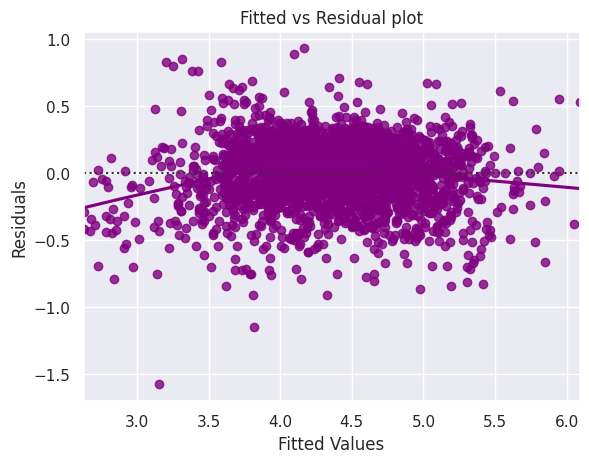

In [291]:
# let's plot the fitted values vs residuals on a residual plot

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

**Observations**

- We see no pattern in the plot above.
- Hence, the assumptions of linearity and independence are satisfied.

### TEST FOR NORMALITY

- We will test for normality by checking the distribution of residuals, by checking the Q-Q plot of residuals, and if first two tests fail, we use the Shapiro-Wilk test.
- If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
- If the p-value of the Shapiro-Wilk test is greater than 0.05, we can say the residuals are normally distributed.

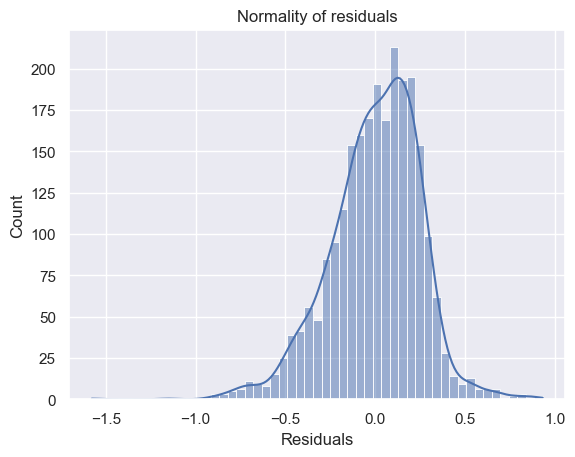

In [131]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

**Observations**

- The histogram of residuals almost has a bell-shaped structure, indicating the normality of the residuals.
- Let's check the Q-Q plot.

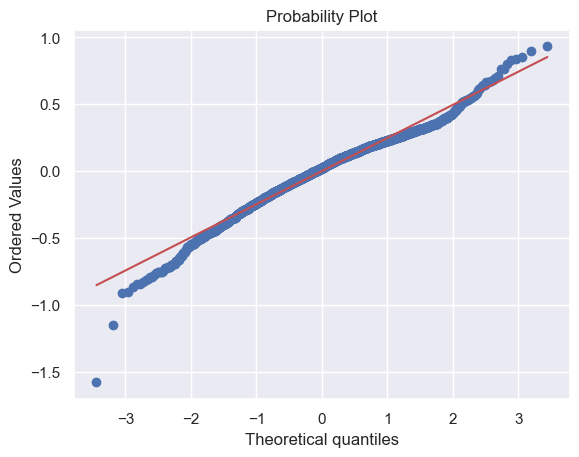

In [134]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

**Observations**

- The bulk of the residuals follows a straight line.
-  Based on the distribution plot and Q-Q plot, we can consider the distribution to be a good approximation of the normal distribution.

We conclude that the assumption for Normality is satisfied.

### TEST FOR HOMOSCEDASTICITY

- We will test for homoscedasticity by using the goldfeldquandt test.
- If we get a p-value greater than 0.05, we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.

    - Null hypothesis: Residuals are homoscedastic
    - Alternate hypothesis: Residuals have heteroscedasticity

In [136]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train_br)
print(lzip(name, test))

# define p_value
p_value = (test[1])

# Interpretation
alpha = 0.05
if p_value < alpha:
    print('Reject the null hypothesis:  Residuals are hetroscedastic.')
else:
    print('Fail to reject the null hypothesis:  Residuals are homoscedastic.')


[('F statistic', 1.000975029630984), ('p-value', 0.49328270330059754)]
Fail to reject the null hypothesis:  Residuals are homoscedastic.


**Observations**

- Since p-value > 0.05, Fail to reject the null hypothesis and conclude that the residuals are homoscedastic.
- So, the assumption is satisfied.

**All the assumptions of linear regression are satisfied. Let's rebuild our final model, check its performance, and draw inferences from it.**

## Final Model

In [138]:
# making the final train and test data
x_train_final = x_train_br.copy()
x_test_final = x_test_br.copy()

In [140]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.817
Model:                               OLS   Adj. R-squared:                  0.816
Method:                    Least Squares   F-statistic:                     765.4
Date:                   Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                           23:07:38   Log-Likelihood:                -76.746
No. Observations:                   2417   AIC:                             183.5
Df Residuals:                       2402   BIC:                             270.3
Df Model:                             14                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [142]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.249777,0.194058,0.816878,0.815734,4.668692


In [144]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test_final, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.253365,0.196261,0.82202,0.819405,4.79571


Get the equation of the linear regression model

In [148]:
# Getting the final equation of the linear regression model

equation_terms = []   # to store the individual terms of the equation

# Loop through each features (columns) in the x_train_final (by index and column name)
for i, feature in enumerate(x_train_final.columns):
    coef = olsmodel_final.params.iloc[i]  # Using iloc to ensure safe indexing and avoid warnings
    if i == 0:
        equation_terms.append(f"{coef:.4f}")  # Format to 4 decimal places
    else:
        equation_terms.append(f"{coef:.4f} * ({feature})")

# Joining the terms into a readable equation
equation = "normalized_used_price = " + " + ".join(equation_terms)

# Print the equation
print(equation)

normalized_used_price = -41.8332 + 0.0145 * (main_camera_mp) + 0.0117 * (selfie_camera_mp) + 0.0192 * (ram) + 0.0001 * (battery) + 0.0214 * (release_year) + 0.4763 * (normalized_new_price) + 0.0599 * (brand_name_Alcatel) + 0.1409 * (brand_name_Karbonn) + 0.0650 * (brand_name_Lenovo) + 0.1396 * (brand_name_Microsoft) + 0.0717 * (brand_name_Nokia) + 0.0745 * (brand_name_Xiaomi) + -0.1454 * (os_Others) + -0.0778 * (5g_yes)


* The model is able to explain ~82% of the variation in the data

* The train and test RMSE and MAE are low and comparable. So, our model is not suffering from overfitting

* The MAPE on the test set suggests we can predict within 4.8% of the anime ratings

* Hence, we can conclude the model *olsmodel_final* is good for prediction as well as inference purposes

# Actionable Insights and Recommendations

1. The model is able to explain ~82% of the variation in the data and make prediction within 4.8% of the normalized used price of the devices on the test data, which is good

2. Comparable RMSE on the train and test sets means that the model is not suffering from overfitting. This further indicates that the model is good for prediction as well as inference purposes.

3. There are several key features affecting the price of used devices. For example, all other variables held constant;

   - If the normalized new price increases by one unit, then its normalized used price increases by 0.4764 units. This high coefficient implies that the new price has a big influence in determining the a used price.

   - If the main camera and selfie camera MP increases by one unit, then its price increases by 0.0145 units, implying that better cameras slightly increase used price.

   - If the release years of the devices increases by one unit, then its used price decreases by 0.0762 units. This implies that Newer phones tend to retain value better.

   - If the device is not a 5G enabled, then its used price decreases by 0.0770 units. This implies that 5G-enabled phones have lower used prices, possibly due to rapid tech evolution.

   - The price of OS_Others (unpopular OS) device decreases by 0.1446. This implies phones with less popular OS depreciate faster.
  
   - The coefficient values of brand names are relatively low, meaning brand alone has a small but significant effect.




___